In [1]:
import numpy as np
import scipy.stats as sps
import xarray as xr
import matplotlib.pyplot as plt
import sys
import urllib
import os

In [2]:
yourdrive = '/content/drive/MyDrive/data/' # Be sure to create this directory in your AIMS google drive area.
# Mount google drive into this runtime
if not os.path.exists('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')
sstdata = yourdrive+'noaaoisst.mon.mean.nc'
if not os.path.exists(sstdata):
    url='https://downloads.psl.noaa.gov/Datasets/noaa.oisst.v2/sst.mnmean.nc'
    urllib.request.urlretrieve(url, sstdata)
    print(f"File downloaded to {sstdata}")
else:
    print(f"File already exists at {sstdata}")
#
rainfall_cmap=yourdrive+'cmapprecip.mon.mean.nc'
if not os.path.exists(rainfall_cmap):
    url='https://downloads.psl.noaa.gov/Datasets/cmap/std/precip.mon.mean.nc'
    urllib.request.urlretrieve(url, rainfall_cmap)
    print(f"File downloaded to {rainfall_cmap}")
else:
    print(f"File already exists at {rainfall_cmap}")

File already exists at /content/drive/MyDrive/data/noaaoisst.mon.mean.nc
File already exists at /content/drive/MyDrive/data/cmapprecip.mon.mean.nc


In [3]:
# Define a index dictionary containing latitude and longitude ranges which define box over which to average for index.
indexdict={}
indexdict['NINO12'] = [-10,0,270,280]
indexdict['NINO3']  = [-5,5,210,270]
indexdict['NINO34'] = [-5,5,190,240]
indexdict['NINO4']  = [-5,5,160,210]
indexdict['BengNINO'] =  [-20,-10,8,15]
indexdict['SIOD']={'west': [-37,-27,55,65]}
indexdict['SIOD']['east']  = [-28,-18,90,100]
indexdict['IOD']={'west':[-10,10,50,70]}
indexdict['IOD']['east'] = [-10,0,90,110]
indexdict['SAsummerRain'] = [-32,-13,23,35]
'''WHERE ARE THIS LOCATED ON A MAP?? USE GOOGLE EARTH OR SIMILAR TO LOCATE THESE AREAS BY DRAWING A PATH/POLYGON WITH MOUSE ON MAP.'''

'WHERE ARE THIS LOCATED ON A MAP?? USE GOOGLE EARTH OR SIMILAR TO LOCATE THESE AREAS BY DRAWING A PATH/POLYGON WITH MOUSE ON MAP.'

In [4]:
### Let us make a function on which we can draw box locations for reference to do this we will install two additional libraries
!pip install cartopy
!pip install cmocean

In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from ipywidgets import interactive, widgets
import numpy as np

def plot_sst_map_with_index(start_year=1982, end_year=2022, vmin=15, vmax=30,
                           season='Annual', sst_index='NINO34'):
    """
    Plot SST map with customizable parameters and highlighted index region
    """
    # Define type of transform
    projection=ccrs.PlateCarree()

    # Create time slice
    time_slice = slice(f'{start_year}-01-01', f'{end_year}-12-31')
    xr_dataset = xr.open_dataset(sstdata)
    data_subset = xr_dataset.sel(time=time_slice)

    # Apply seasonal selection if needed
    if season != 'Annual':
        data_subset = data_subset.sel(time=data_subset.time.dt.season == season)

    # Compute mean
    sst_mean = data_subset.sst.mean(dim='time')

    # Create plot
    fig = plt.figure(figsize=(15, 8))
    ax = plt.axes(projection=projection)

    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.gridlines()

    # Plot SST data
    plot = sst_mean.plot(
        transform=projection,
        cmap=cmocean.cm.thermal,
        vmin=vmin,
        vmax=vmax,
        cbar_kwargs={
            'label': 'Sea Surface Temperature (°C)',
            'orientation': 'horizontal',
            'extend': 'both'
        },
        ax=ax
    )

    # Highlight selected index region
    region = indexdict[sst_index]
    if isinstance(region, list):
        lat1, lat2, lon1, lon2 = region
        # Draw rectangle for index region
        ax.add_patch(
            plt.Rectangle(
                xy=[lon1, lat1],
                width=lon2-lon1,
                height=lat2-lat1,
                facecolor='none',
                edgecolor='red',
                linewidth=2,
                transform=projection
            )
        )

        # Calculate index statistics
        region_data = data_subset.sel(
            lat=slice(lat2, lat1),
            lon=slice(lon1, lon2)
        ).sst

        # Calculate mean using numpy's nanmean to handle missing values
        mean_sst = np.nanmean(region_data.values)
        std_sst = np.nanstd(region_data.values)

    elif isinstance(region, dict):
        # For dipole indices, draw two boxes
        colors = ['red', 'blue']
        stats = {}
        for i, (key, bounds) in enumerate(region.items()):
            lat1, lat2, lon1, lon2 = bounds
            ax.add_patch(
                plt.Rectangle(
                    xy=[lon1, lat1],
                    width=lon2-lon1,
                    height=lat2-lat1,
                    facecolor='none',
                    edgecolor=colors[i],
                    linewidth=2,
                    transform=projection
                )
            )
            # Calculate statistics for each box
            box_data = data_subset.sel(
                lat=slice(lat2, lat1),
                lon=slice(lon1, lon2)
            ).sst
            stats[key] = np.nanmean(box_data.values)

    # Add title with information
    title = f'Mean Sea Surface Temperature ({start_year}-{end_year})\n{sst_index} Region'
    if season != 'Annual':
        title += f' - Season: {season}'
    plt.title(title, pad=20, size=14)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"\nStatistics for {sst_index} region:")
    if isinstance(region, list):
        print(f"Mean Temperature: {mean_sst:.2f}°C")
        print(f"Standard Deviation: {std_sst:.2f}°C")
        print(f"Region bounds: Lat [{lat1}°, {lat2}°], Lon [{lon1}°, {lon2}°]")
    else:
        print("Dipole Index Statistics:")
        west_mean = stats['west']
        east_mean = stats['east']
        print(f"Western box mean: {west_mean:.2f}°C")
        print(f"Eastern box mean: {east_mean:.2f}°C")

# Create interactive controls
interactive_plot = interactive(
    plot_sst_map_with_index,
    start_year=widgets.IntSlider(min=1982, max=2022, step=1, value=1982, description='Start Year'),
    end_year=widgets.IntSlider(min=1982, max=2022, step=1, value=2022, description='End Year'),
    vmin=widgets.FloatSlider(min=-5, max=10, step=0.5, value=0, description='Min Temp'),
    vmax=widgets.FloatSlider(min=20, max=35, step=0.5, value=30, description='Max Temp'),
    season=widgets.Dropdown(
        options=['Annual', 'DJF', 'MAM', 'JJA', 'SON'],
        value='Annual',
        description='Season'
    ),
    sst_index=widgets.Dropdown(
        options=list(indexdict.keys()),
        value='NINO34',
        description='SST Index'
    )
)

# Display the interactive plot
interactive_plot

interactive(children=(IntSlider(value=1982, description='Start Year', max=2022, min=1982), IntSlider(value=202…

In [6]:
def climate_index(datafile,whichindex,varname='sst'):
    '''CAREFULLY GO THROUGH THIS FUNCTION AND UNDERSTANDING EACH LINE OF CODE
    WHAT IS THE FUdata_area = xr.open_dataset(datafile)NCTION PRODUCING? WHAT DOES IT TAKE AS INPUT.
    NOW WRITE A CORRECT DESCRIPTION AND USAGE GUIDANCE FOR THIS FUNCTION HERE IN PLACE OF THIS TEXT.'''
    time_range = slice('1982-01-01','2022-12-31')
    indx = indexdict[whichindex]
    if isinstance(indx,list):
        lt1,lt2,ln1,ln2 = indx
        lat_range, lon_range = slice(lt2,lt1), slice(ln1,ln2)
        data_area = xr.open_dataset(datafile).sel(lat=lat_range,lon=lon_range,time=time_range)
        dtime = data_area.time
        timemonth = dtime.dt.month
        # index = data_area.mean('lon').mean('lat') ### Alt. using xarray
        data = data_area[varname]
        index = np.nanmean(data,(1,2)) # Ensures nans are managed
        index_anoms = np.zeros(index.shape)
        index_std = np.zeros(index.shape)
        for i in np.arange(1,13):
            ix = np.where(timemonth[:] == i)
            index_std[ix] = sps.zscore(index[ix])
            index_anoms[ix] = index[ix]-np.nanmean(index[ix])
    elif isinstance(indx,dict):
        index_std_dict = {}
        for ky in ['west','east']:
            lt1,lt2,ln1,ln2 = indx[ky]
            lat_range, lon_range = slice(lt2,lt1), slice(ln1,ln2)
            data_area = xr.open_dataset(datafile).sel(lat=lat_range,lon=lon_range,time=time_range)
            dtime = data_area.time
            timemonth = dtime.dt.month
            # index = data_area.mean('lon').mean('lat') ### Alt. using xarray
            data = data_area[varname]
            index = np.nanmean(data,(1,2)) # Ensures nans are managed
            index_anoms = np.zeros(index.shape)
            index_std = np.zeros(index.shape)
            for i in np.arange(1,13):
                ix = np.where(timemonth[:] == i)
                index_std[ix] = sps.zscore(index[ix])
                index_anoms[ix] = index[ix]-np.nanmean(index[ix])
            index_std_dict[ky] = index_std
        index_std = index_std_dict['west'] - index_std_dict['east']

    #return dtime, index_std, index_anoms, index
    return dtime, index_std

In [7]:
dtime, nino34 = climate_index(sstdata,'NINO34')
dtime, siod = climate_index(sstdata,'SIOD')
dtime, iod = climate_index(sstdata,'IOD')
dtime, biod = climate_index(sstdata,'BengNINO')
dtime, sa_rain = climate_index(rainfall_cmap,'SAsummerRain',varname='precip')
decimal_year = dtime.dt.year + (dtime.dt.month/12.-1/24.) # mid-month decimal yr

In [8]:
data = np.vstack((nino34,siod,iod,biod,sa_rain)).T
var_names = ['nino34','siod','iod', 'Bnino','SA_rain']

In [9]:
maskDJF = np.ones(data.shape, dtype=bool)
dtmonths=dtime.dt.month
for ix,mn in enumerate(dtmonths):
        if mn in [12,1,2]:
            maskDJF[ix,:] = False

ixDJF = np.where(~maskDJF[:,0])[0]

In previous notebook, we simply used numpy and scipy.stats functions to compute correlations between timeseries. However now we want to get ready to use causal inference approaches on this data. To do so we will install tigramite https://github.com/jakobrunge/tigramite. First we install dependencies as per environment guidance on github page:

In [10]:
reqfile = 'requirements.txt'
f = open(reqfile, 'w')
f.write('''
numba>=0.58
scikit-learn>=1.2
matplotlib>=3.7.0
seaborn>=0.12.2
dcor>=0.6
joblib>=1.2.0
ortools>=9.2
''')
f.close()
!pip install -r requirements.txt

At this point you probably need to restart the runtime environment. Do not worry about particular errors that this pip install may create, they seem to resolve once restarting environment. Be sure to press run all again to bring all data and functions above here back to life!

Now we shoudd install tigramite.

In [11]:
!pip install tigramite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.7/314.7 kB 6.4 MB/s eta 0:00:00


(<Figure size 640x480 with 5 Axes>,
 array([<Axes: ylabel='nino34'>, <Axes: ylabel='siod'>,
        <Axes: ylabel='iod'>, <Axes: ylabel='Bnino'>,
        <Axes: ylabel='SA_rain'>], dtype=object))

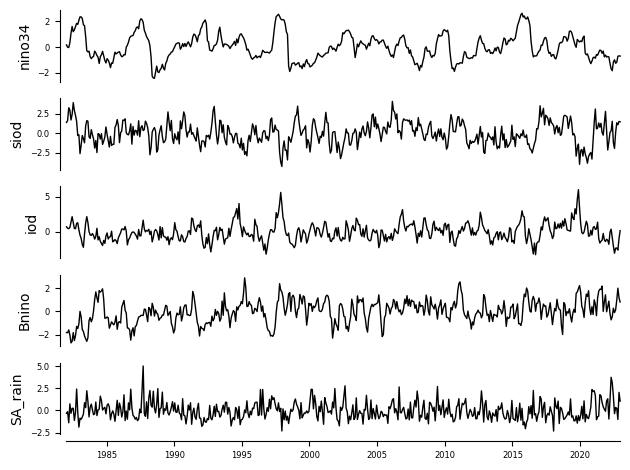

In [12]:
import tigramite
import tigramite.data_processing as pp
import tigramite.plotting as tp

dataframe = pp.DataFrame(data,datatime = decimal_year, var_names=var_names)
tp.plot_timeseries(dataframe)

(<Figure size 640x480 with 5 Axes>,
 array([<Axes: ylabel='nino34'>, <Axes: ylabel='siod'>,
        <Axes: ylabel='iod'>, <Axes: ylabel='Bnino'>,
        <Axes: ylabel='SA_rain'>], dtype=object))

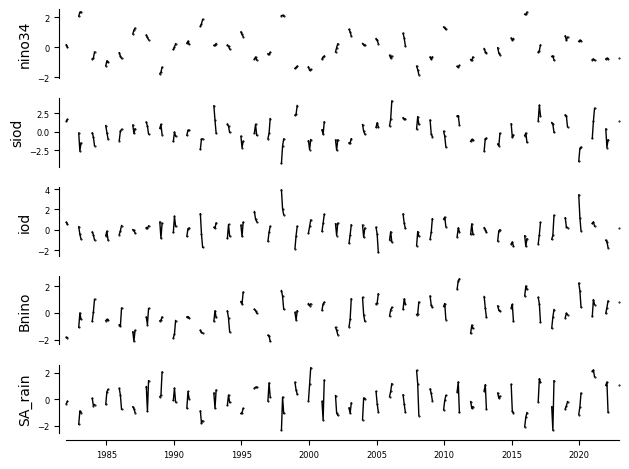

In [13]:
### Mask out months not within core wet season months of Dec, Jan, Feb and plot
dataframe = pp.DataFrame(np.copy(data), datatime=decimal_year, var_names=var_names, mask=maskDJF)
tp.plot_timeseries(dataframe)

In [14]:
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(
    dataframe=dataframe,
    cond_ind_test=parcorr,
    verbosity=1)
correlations = pcmci.get_lagged_dependencies(tau_max=3, val_only=True)['val_matrix']


##
## Estimating lagged dependencies 
##

Parameters:

independence test = par_corr
tau_min = 0
tau_max = 3


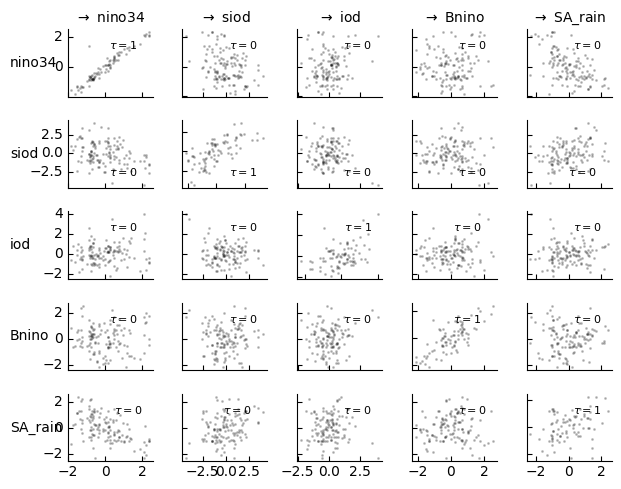

In [15]:
matrix_lags = None #np.argmax(np.abs(correlations), axis=2)
tp.plot_scatterplots(dataframe=dataframe, add_scatterplot_args={'matrix_lags':matrix_lags}); plt.show()

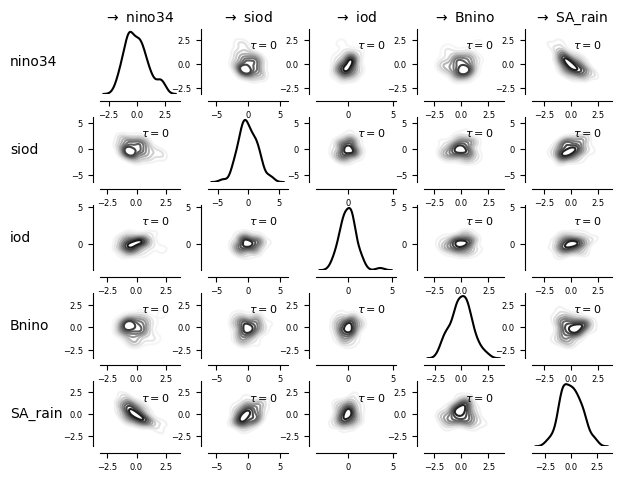

In [16]:
tp.plot_densityplots(dataframe=dataframe, add_densityplot_args={'matrix_lags':matrix_lags})
plt.show()

Now try to build a hypothesized causal effect graph. On a piece of paper sketch out the causal graph you wish to create and test between climate indices you have computed here.

To understand protocol to translate this graph into code understood by tigramite start by following the tutorial on tigramite that Jakob Runge as set up.

1. https://github.com/jakobrunge/tigramite
2. Find tutorials --> case studies --> climate case study
3. See information on how to build a graph.
4. Translate your sketch into the code patterns you learnt from the climate case study tutorial.